In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [4]:
df = pd.read_csv("knn_telecom.csv")

In [5]:
le_gender = LabelEncoder()
le_plan = LabelEncoder()

In [6]:
df["Gender"] = le_gender.fit_transform(df["Gender"])
df["PlanType"] = le_plan.fit_transform(df["PlanType"])

In [7]:
X = df.drop("Churn", axis =1)
y = df["Churn"]

In [8]:
scaler = StandardScaler()

In [10]:
X_scaled = scaler.fit_transform(X)

In [11]:
skf = StratifiedKFold(n_splits=3 , shuffle = True, random_state = 42)

In [15]:
k_values = range(1,8)
cv_scores =[]

In [18]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=skf , scoring ="accuracy")
    cv_scores.append(scores.mean())

In [19]:
for k , score in zip(k_values,cv_scores):
    print("K = ", k, "| Cross Validation Accuracy = ",round(score,3))

K =  1 | Cross Validation Accuracy =  0.967
K =  2 | Cross Validation Accuracy =  0.953
K =  3 | Cross Validation Accuracy =  0.973
K =  4 | Cross Validation Accuracy =  0.96
K =  5 | Cross Validation Accuracy =  0.973
K =  6 | Cross Validation Accuracy =  0.953
K =  7 | Cross Validation Accuracy =  0.953


In [22]:
best_k = k_values[np.argmax(cv_scores)]
print("\nBest K: ", best_k)


Best K:  3


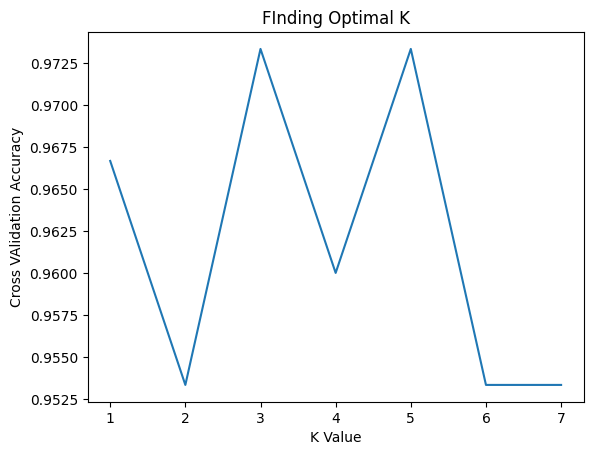

In [23]:
plt.plot(k_values, cv_scores)
plt.xlabel("K Value")
plt.ylabel("Cross VAlidation Accuracy")
plt.title("FInding Optimal K")
plt.show()